# Spatial fiber-field remodeling under compatible prescribed kinematics

This notebook extends the homogeneous material-point example to two-dimensional fields

\[
\mathbf a_0=\mathbf a_0(X,Y,t),
\qquad
\beta=\beta(X,Y,t).
\]

The sample is discretized on a rectangular reference grid. Each grid point follows the same finite-strain constitutive and remodeling equations as in Notebook 01, while the prescribed deformation gradient varies smoothly across the sample.

The central questions are:

1. Can a smooth heterogeneous orientation field be evolved without violating nematic symmetry?
2. Can the structural-order parameter remain bounded at every material point?
3. Can spatially varying compatible kinematics generate spatially varying remodeling?
4. How do orientation, structural order, stress, and energy co-evolve?

> **Important limitation.** This is not yet a finite-element equilibrium solution. Material points are locally uncoupled after the compatible kinematic field has been prescribed. No spatial diffusion, nonlocal regularization, or force-balance solve is included in version 0.2.

## 1. Reproducible environment

The notebook finds the repository root automatically and imports the package from `src/` when it has not been installed in editable mode.

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (  # noqa: E402
    MaterialParameters,
    RemodelingParameters,
    SpatialSimulationConfig,
    compatible_shear_extension_deformation,
    principal_stretch_direction,
    run_spatial_remodeling,
)
from anisotropic_remodeling.spatial import rectangular_grid  # noqa: E402

np.set_printoptions(precision=6, suppress=True)
print(f"Repository root: {REPOSITORY_ROOT}")
print(f"NumPy version: {np.__version__}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
NumPy version: 1.24.3


## 2. Compatible heterogeneous deformation

The prescribed motion is

\[
x=\lambda(t)X-\frac{\gamma(t)H}{\pi}\cos\left(\frac{\pi Y}{H}\right),
\qquad
y=\frac{Y}{\lambda(t)},
\]

where \(H\) is the half-height of the sample. Therefore,

\[
\mathbf F(X,Y,t)=
\begin{bmatrix}
\lambda(t) & \gamma(t)\sin\left(\frac{\pi Y}{H}\right)\\
0 & \lambda(t)^{-1}
\end{bmatrix},
\qquad
\det\mathbf F=1.
\]

Unlike an arbitrary pointwise assignment of \(\mathbf F\), this field is the gradient of a smooth deformation mapping. It combines area-preserving extension with a shear component that changes sign across the midline.

In [2]:
config = SpatialSimulationConfig(
    nx=61,
    ny=41,
    half_width=1.5,
    half_height=1.0,
    total_time=20.0,
    dt=0.1,
    ramp_duration=5.0,
    maximum_stretch=1.18,
    maximum_shear=0.35,
    mean_fiber_angle_deg=45.0,
    angle_amplitude_deg=25.0,
    beta_background=0.35,
    beta_defect_depth=0.22,
    defect_center_x=0.30,
    defect_center_y=-0.15,
    defect_width_x=0.35,
    defect_width_y=0.25,
)

material = MaterialParameters(mu=10.0, kappa=1000.0, k1=2.0, k2=5.0)
remodeling = RemodelingParameters(
    orientation_rate=0.25,
    order_rate=0.15,
    beta_min=0.10,
    beta_max=1.00,
    half_saturation=0.20,
    hill_exponent=2.0,
)

for title, parameters in (
    ("Spatial configuration", config),
    ("Material parameters", material),
    ("Remodeling parameters", remodeling),
):
    print(title)
    for name, value in asdict(parameters).items():
        print(f"  {name}: {value}")
    print()

Spatial configuration
  nx: 61
  ny: 41
  half_width: 1.5
  half_height: 1.0
  total_time: 20.0
  dt: 0.1
  ramp_duration: 5.0
  maximum_stretch: 1.18
  maximum_shear: 0.35
  mean_fiber_angle_deg: 45.0
  angle_amplitude_deg: 25.0
  beta_background: 0.35
  beta_defect_depth: 0.22
  defect_center_x: 0.3
  defect_center_y: -0.15
  defect_width_x: 0.35
  defect_width_y: 0.25

Material parameters
  mu: 10.0
  kappa: 1000.0
  k1: 2.0
  k2: 5.0

Remodeling parameters
  orientation_rate: 0.25
  order_rate: 0.15
  beta_min: 0.1
  beta_max: 1.0
  half_saturation: 0.2
  hill_exponent: 2.0



### 2.1 Reference and deformed grids

The visualization below uses the same mapping from which the deformation gradient is derived.

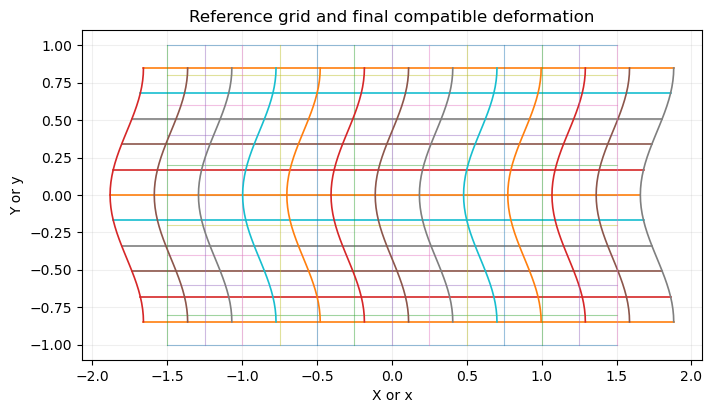

In [3]:
x, y = rectangular_grid(config)
load_fraction = 1.0
stretch = config.maximum_stretch
shear = config.maximum_shear

x_deformed = (
    stretch * x
    - shear * config.half_height / np.pi
    * np.cos(np.pi * y / config.half_height)
)
y_deformed = y / stretch

figure, axis = plt.subplots(figsize=(8, 5))
line_stride_x = 5
line_stride_y = 4
for row in range(0, config.ny, line_stride_y):
    axis.plot(x[row], y[row], linewidth=0.8, alpha=0.45)
    axis.plot(x_deformed[row], y_deformed[row], linewidth=1.2)
for column in range(0, config.nx, line_stride_x):
    axis.plot(x[:, column], y[:, column], linewidth=0.8, alpha=0.45)
    axis.plot(x_deformed[:, column], y_deformed[:, column], linewidth=1.2)
axis.set(
    xlabel="X or x",
    ylabel="Y or y",
    title="Reference grid and final compatible deformation",
    aspect="equal",
)
axis.grid(True, alpha=0.2)
plt.show()

### 2.2 Pointwise Jacobian check

In [4]:
F_final = compatible_shear_extension_deformation(
    y,
    config.ramp_duration,
    half_height=config.half_height,
    maximum_stretch=config.maximum_stretch,
    maximum_shear=config.maximum_shear,
    ramp_duration=config.ramp_duration,
)
J_final = np.linalg.det(F_final)
print(f"Minimum J: {J_final.min():.12f}")
print(f"Maximum J: {J_final.max():.12f}")
assert np.allclose(J_final, 1.0, atol=1.0e-12)

Minimum J: 1.000000000000
Maximum J: 1.000000000000


## 3. Synthetic initial microstructure

The initial angle field is smooth and nematic:

\[
\theta_0(X,Y)=\bar\theta+	heta_a
\sin\left(\frac{\pi X}{2L}\right)
\cos\left(\frac{\pi Y}{2H}\right).
\]

The initial structural-order field contains a localized Gaussian low-order region. This synthetic defect provides a controlled test of bounded field evolution.

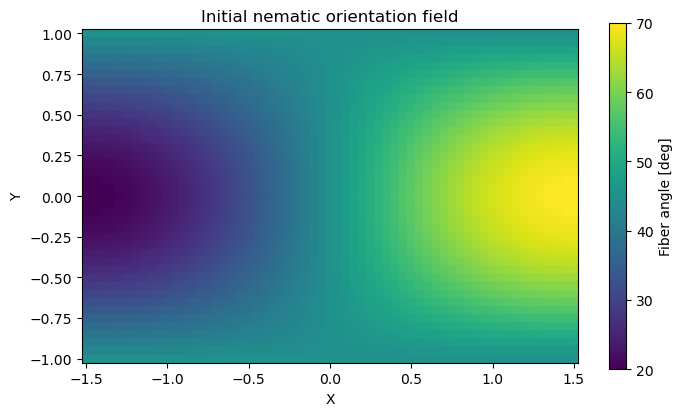

In [5]:
initial_result = run_spatial_remodeling(
    SpatialSimulationConfig(**{**asdict(config), "total_time": config.dt, "ramp_duration": config.dt}),
    material,
    remodeling,
    snapshot_times=(0.0,),
)
initial_angle = initial_result.fiber_angle_deg[0]
initial_beta = initial_result.structural_order[0]

figure, axis = plt.subplots(figsize=(8, 4.5))
image = axis.pcolormesh(x, y, initial_angle, shading="auto")
figure.colorbar(image, ax=axis, label="Fiber angle [deg]")
axis.set(xlabel="X", ylabel="Y", title="Initial nematic orientation field", aspect="equal")
plt.show()

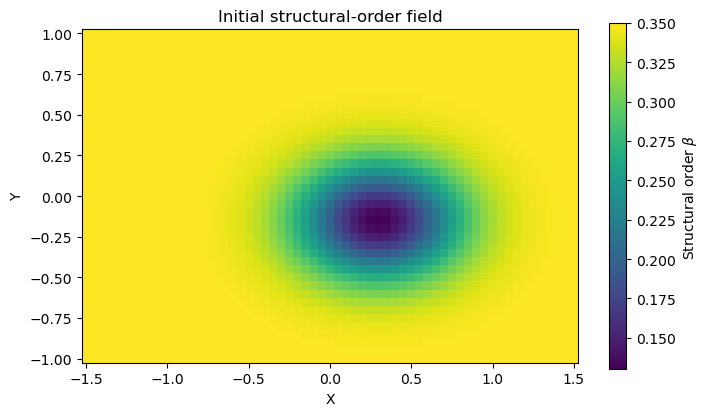

In [6]:
figure, axis = plt.subplots(figsize=(8, 4.5))
image = axis.pcolormesh(x, y, initial_beta, shading="auto")
figure.colorbar(image, ax=axis, label=r"Structural order $\beta$")
axis.set(xlabel="X", ylabel="Y", title="Initial structural-order field", aspect="equal")
plt.show()

### 3.1 Undirected orientation segments

Lines rather than arrows are used because a fiber direction satisfies \(\mathbf a_0\equiv-\mathbf a_0\).

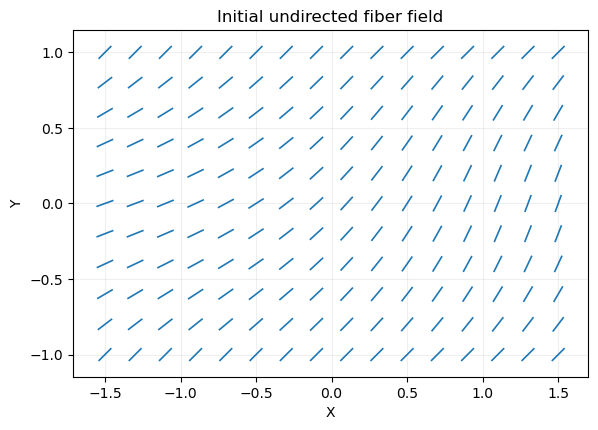

In [7]:
def add_nematic_segments(axis, x_field, y_field, fiber_field, *, stride=4, length=0.12):
    x_sample = x_field[::stride, ::stride]
    y_sample = y_field[::stride, ::stride]
    fiber_sample = fiber_field[::stride, ::stride]
    half = 0.5 * length
    start = np.stack(
        (x_sample - half * fiber_sample[..., 0], y_sample - half * fiber_sample[..., 1]),
        axis=-1,
    )
    end = np.stack(
        (x_sample + half * fiber_sample[..., 0], y_sample + half * fiber_sample[..., 1]),
        axis=-1,
    )
    segments = np.stack((start, end), axis=-2).reshape(-1, 2, 2)
    collection = LineCollection(segments, linewidths=1.2)
    axis.add_collection(collection)
    axis.autoscale_view()


figure, axis = plt.subplots(figsize=(8, 4.5))
add_nematic_segments(axis, x, y, initial_result.fiber_direction[0])
axis.set(xlabel="X", ylabel="Y", title="Initial undirected fiber field", aspect="equal")
axis.grid(True, alpha=0.2)
plt.show()

## 4. Run the spatial remodeling simulation

Three field snapshots are retained: the initial state, the end of the loading ramp, and the final remodeled state. Global spatial averages are stored at every time step.

In [8]:
result = run_spatial_remodeling(
    config,
    material,
    remodeling,
    snapshot_times=(0.0, config.ramp_duration, config.total_time),
)

print(f"Grid points: {config.nx * config.ny}")
print(f"Time points: {result.time.size}")
print(f"Snapshot times: {result.snapshot_time}")
print(f"Initial mean beta: {result.mean_structural_order[0]:.6f}")
print(f"Final mean beta:   {result.mean_structural_order[-1]:.6f}")
print(f"Initial coherence: {result.orientation_coherence[0]:.6f}")
print(f"Final coherence:   {result.orientation_coherence[-1]:.6f}")
print(f"Final target alignment: {result.mean_target_alignment[-1]:.6f}")

Grid points: 2501
Time points: 201
Snapshot times: [ 0.  5. 20.]
Initial mean beta: 0.330664
Final mean beta:   0.779554
Initial coherence: 0.908952
Final coherence:   0.768275
Final target alignment: 0.999293


## 5. Spatial evolution of fiber orientation

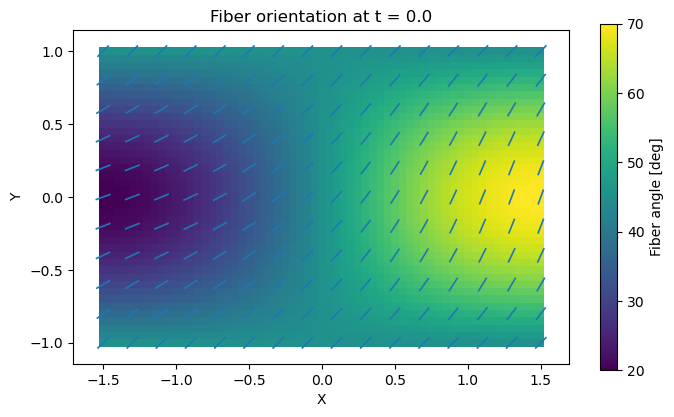

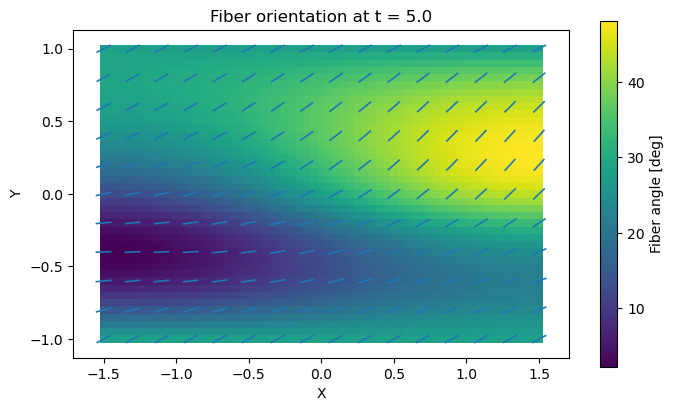

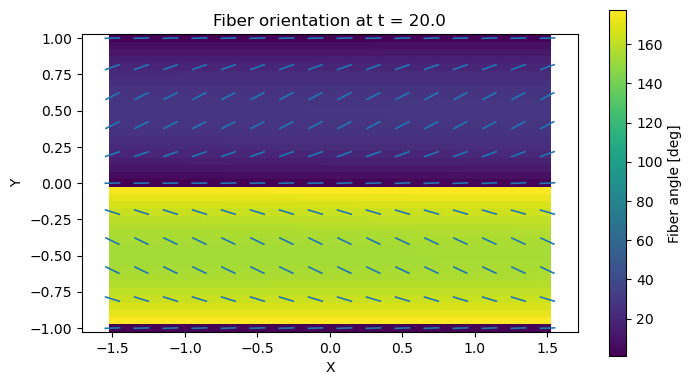

In [9]:
for snapshot_index, snapshot_time in enumerate(result.snapshot_time):
    figure, axis = plt.subplots(figsize=(8, 4.5))
    image = axis.pcolormesh(
        result.x,
        result.y,
        result.fiber_angle_deg[snapshot_index],
        shading="auto",
    )
    figure.colorbar(image, ax=axis, label="Fiber angle [deg]")
    add_nematic_segments(
        axis,
        result.x,
        result.y,
        result.fiber_direction[snapshot_index],
        stride=4,
        length=0.11,
    )
    axis.set(
        xlabel="X",
        ylabel="Y",
        title=f"Fiber orientation at t = {snapshot_time:.1f}",
        aspect="equal",
    )
    plt.show()

The upper and lower halves develop different preferred angles because the prescribed shear changes sign across the midline. The representation remains nematic, so angle jumps near \(0^\circ/180^\circ\) do not indicate a physical discontinuity.

## 6. Spatial evolution of structural order

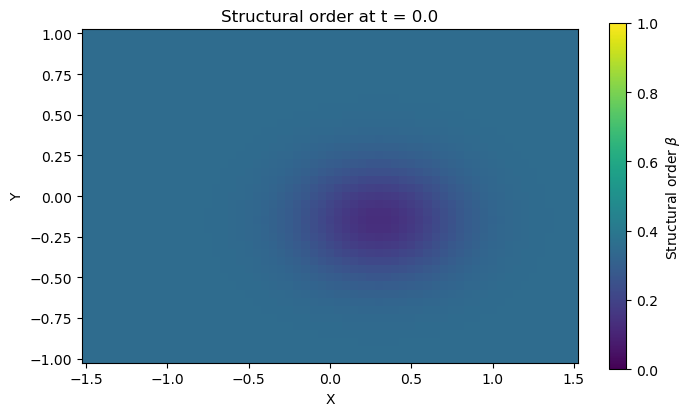

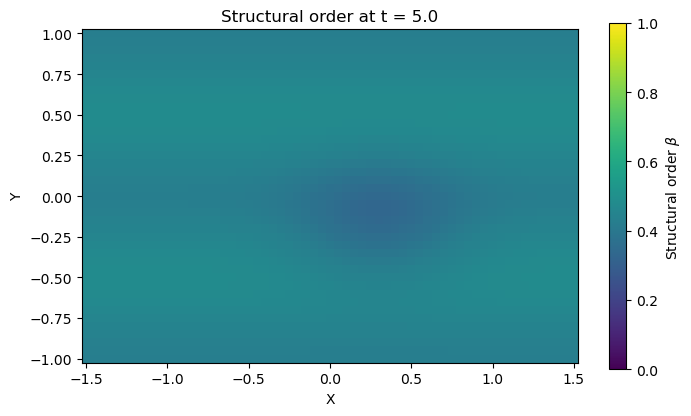

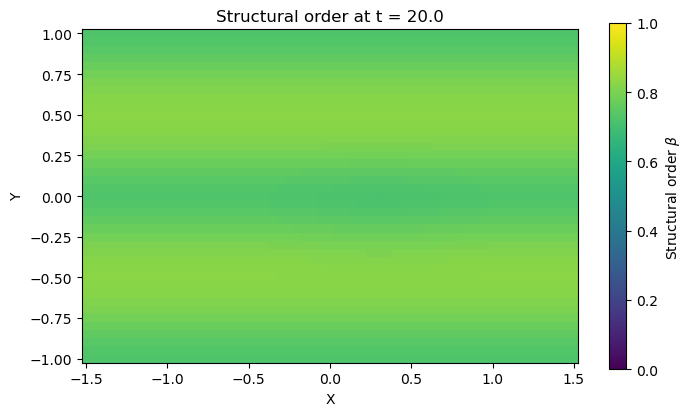

In [10]:
for snapshot_index, snapshot_time in enumerate(result.snapshot_time):
    figure, axis = plt.subplots(figsize=(8, 4.5))
    image = axis.pcolormesh(
        result.x,
        result.y,
        result.structural_order[snapshot_index],
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )
    figure.colorbar(image, ax=axis, label=r"Structural order $\beta$")
    axis.set(
        xlabel="X",
        ylabel="Y",
        title=f"Structural order at t = {snapshot_time:.1f}",
        aspect="equal",
    )
    plt.show()

The low-order defect does not disappear instantaneously. It relaxes locally toward the mechanically determined equilibrium field with the finite kinetic rate \(k_\beta\).

## 7. Mechanical stimulus and target direction

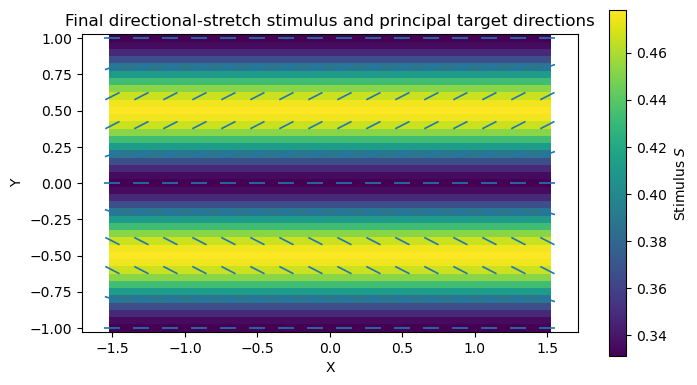

In [11]:
final_stimulus = result.stimulus[-1]
final_target = principal_stretch_direction(result.deformation_gradient[-1])

figure, axis = plt.subplots(figsize=(8, 4.5))
image = axis.pcolormesh(result.x, result.y, final_stimulus, shading="auto")
figure.colorbar(image, ax=axis, label=r"Stimulus $S$")
add_nematic_segments(axis, result.x, result.y, final_target, stride=4, length=0.11)
axis.set(
    xlabel="X",
    ylabel="Y",
    title="Final directional-stretch stimulus and principal target directions",
    aspect="equal",
)
plt.show()

## 8. Energy and stress fields after remodeling

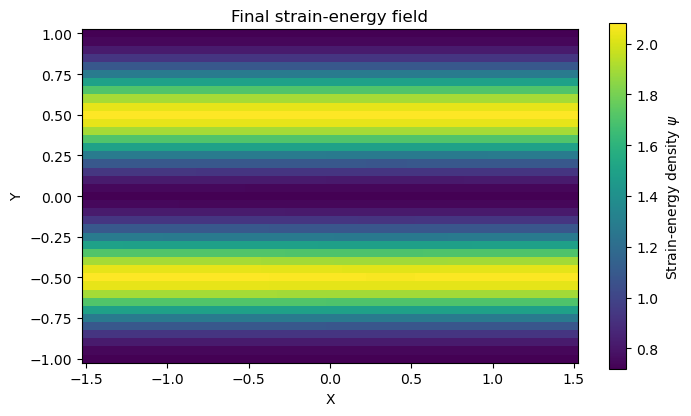

In [12]:
figure, axis = plt.subplots(figsize=(8, 4.5))
image = axis.pcolormesh(
    result.x,
    result.y,
    result.strain_energy[-1],
    shading="auto",
)
figure.colorbar(image, ax=axis, label=r"Strain-energy density $\psi$")
axis.set(xlabel="X", ylabel="Y", title="Final strain-energy field", aspect="equal")
plt.show()

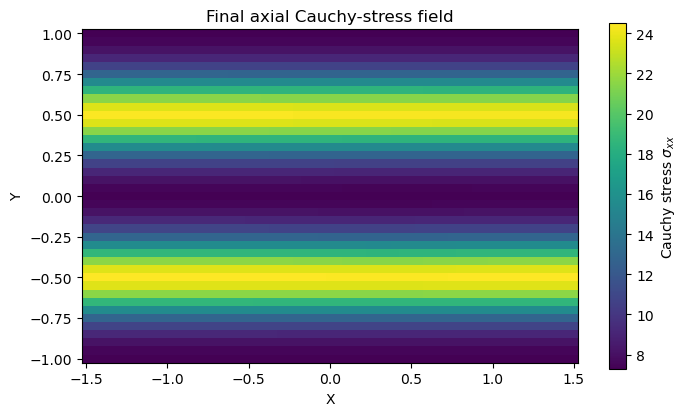

In [13]:
figure, axis = plt.subplots(figsize=(8, 4.5))
image = axis.pcolormesh(
    result.x,
    result.y,
    result.cauchy_stress[-1, ..., 0, 0],
    shading="auto",
)
figure.colorbar(image, ax=axis, label=r"Cauchy stress $\sigma_{xx}$")
axis.set(xlabel="X", ylabel="Y", title="Final axial Cauchy-stress field", aspect="equal")
plt.show()

## 9. Global histories

Spatial averages do not replace local fields, but they provide compact regression quantities for future versions of the code.

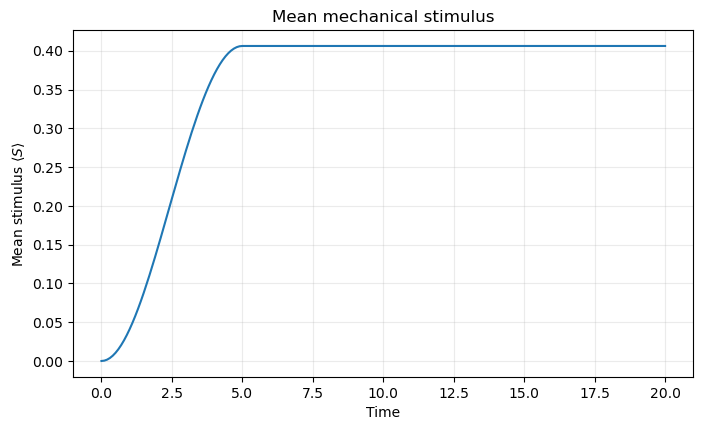

In [14]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_stimulus)
axis.set(xlabel="Time", ylabel=r"Mean stimulus $\langle S\rangle$", title="Mean mechanical stimulus")
axis.grid(True, alpha=0.25)
plt.show()

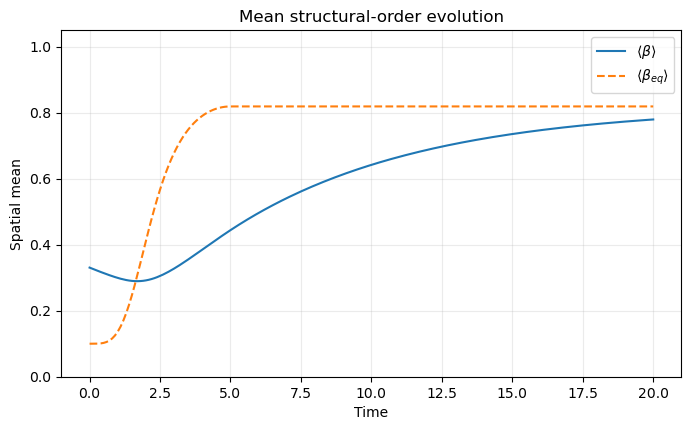

In [15]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_structural_order, label=r"$\langle\beta\rangle$")
axis.plot(result.time, result.mean_equilibrium_order, linestyle="--", label=r"$\langle\beta_{eq}\rangle$")
axis.set(xlabel="Time", ylabel="Spatial mean", title="Mean structural-order evolution", ylim=(0.0, 1.05))
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

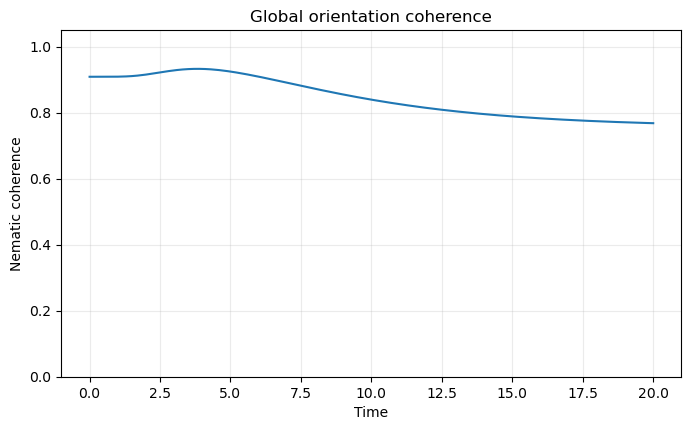

In [16]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.orientation_coherence)
axis.set(xlabel="Time", ylabel="Nematic coherence", title="Global orientation coherence", ylim=(0.0, 1.05))
axis.grid(True, alpha=0.25)
plt.show()

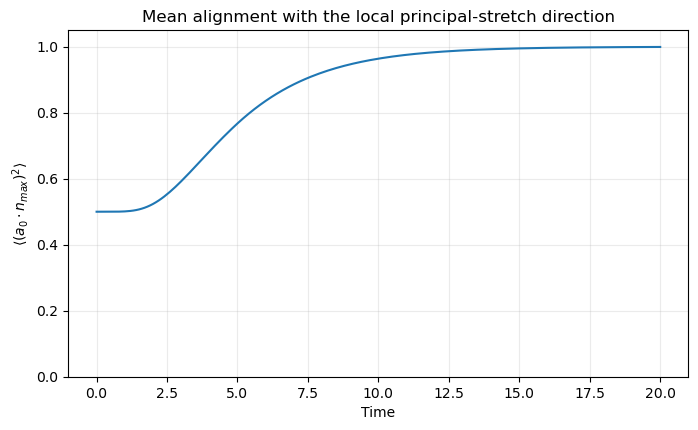

In [22]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_target_alignment)
axis.set(
    xlabel="Time",
    ylabel=r"$\langle(a_0\cdot n_{max})^2\rangle$",
    title="Mean alignment with the local principal-stretch direction",
    ylim=(0.0, 1.05),
)
axis.grid(True, alpha=0.25)
plt.show()

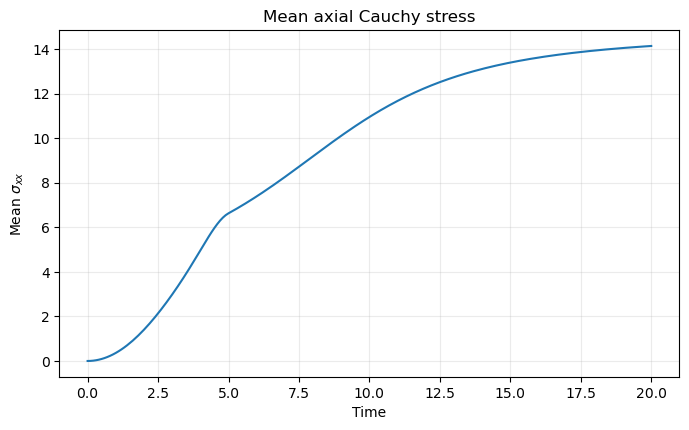

In [18]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_cauchy_stress_xx)
axis.set(xlabel="Time", ylabel=r"Mean $\sigma_{xx}$", title="Mean axial Cauchy stress")
axis.grid(True, alpha=0.25)
plt.show()

## 10. Physical and numerical checks

In [19]:
determinants = np.linalg.det(result.deformation_gradient)
fiber_norms = np.linalg.norm(result.fiber_direction, axis=-1)
stress_asymmetry = np.max(
    np.abs(result.cauchy_stress - np.swapaxes(result.cauchy_stress, -1, -2))
)
final_stimulus_mirror_error = np.max(
    np.abs(result.stimulus[-1] - np.flip(result.stimulus[-1], axis=0))
)

checks = {
    "positive Jacobian": bool(np.all(determinants > 0.0)),
    "area preservation": bool(np.allclose(determinants, 1.0, atol=1.0e-12)),
    "unit fiber vectors": bool(np.allclose(fiber_norms, 1.0, atol=1.0e-12)),
    "bounded beta": bool(np.all((result.structural_order >= 0.0) & (result.structural_order <= 1.0))),
    "finite fields": bool(
        np.all(np.isfinite(result.strain_energy))
        and np.all(np.isfinite(result.cauchy_stress))
    ),
    "symmetric Cauchy stress": bool(stress_asymmetry < 1.0e-10),
    "mirror-symmetric stimulus": bool(final_stimulus_mirror_error < 1.0e-12),
    "increased target alignment": bool(
        result.mean_target_alignment[-1] > result.mean_target_alignment[1]
    ),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")

print(f"Maximum stress asymmetry: {stress_asymmetry:.3e}")
print(f"Stimulus mirror error:    {final_stimulus_mirror_error:.3e}")
assert all(checks.values())

PASS — positive Jacobian
PASS — area preservation
PASS — unit fiber vectors
PASS — bounded beta
PASS — finite fields
PASS — symmetric Cauchy stress
PASS — mirror-symmetric stimulus
PASS — increased target alignment
Maximum stress asymmetry: 3.553e-15
Stimulus mirror error:    3.331e-16


## 11. Grid-sampling study

There are no spatial derivatives in the remodeling law yet. Consequently, grid refinement does not solve a spatial convergence problem in the finite-element sense; it only refines the sampling of smooth prescribed fields and their spatial averages. This study verifies that the reported averages are not artifacts of a very coarse grid.

In [20]:
grid_sizes = ((31, 21), (61, 41), (91, 61))
rows = []
for nx, ny in grid_sizes:
    grid_config = SpatialSimulationConfig(**{**asdict(config), "nx": nx, "ny": ny})
    grid_result = run_spatial_remodeling(
        grid_config,
        material,
        remodeling,
        snapshot_times=(0.0, config.total_time),
    )
    rows.append(
        (
            nx,
            ny,
            grid_result.mean_structural_order[-1],
            grid_result.orientation_coherence[-1],
            grid_result.mean_cauchy_stress_xx[-1],
        )
    )

header = f"{'nx':>5} {'ny':>5} {'mean beta':>14} {'coherence':>14} {'mean sigma_xx':>18}"
print(header)
print("-" * len(header))
for nx, ny, beta_mean, coherence, stress_mean in rows:
    print(f"{nx:5d} {ny:5d} {beta_mean:14.10f} {coherence:14.10f} {stress_mean:18.10f}")

   nx    ny      mean beta      coherence      mean sigma_xx
------------------------------------------------------------
   31    21   0.7782457464   0.7737883439      13.9840325411
   61    41   0.7795536919   0.7682745237      14.1463729968
   91    61   0.7800038626   0.7663763656      14.2022598061


## 12. Export reproducible field data

The compressed NPZ file stores all selected snapshots. The CSV file stores the global time histories. Both can be used by later notebooks without rerunning the simulation.

In [21]:
data_directory = REPOSITORY_ROOT / "results" / "data"
data_directory.mkdir(parents=True, exist_ok=True)

npz_path = data_directory / "spatial_remodeling_snapshots.npz"
np.savez_compressed(
    npz_path,
    x=result.x,
    y=result.y,
    snapshot_time=result.snapshot_time,
    deformation_gradient=result.deformation_gradient,
    fiber_direction=result.fiber_direction,
    fiber_angle_deg=result.fiber_angle_deg,
    structural_order=result.structural_order,
    equilibrium_order=result.equilibrium_order,
    stimulus=result.stimulus,
    strain_energy=result.strain_energy,
    cauchy_stress=result.cauchy_stress,
)

csv_path = data_directory / "spatial_remodeling_global_history.csv"
summary = np.column_stack(
    (
        result.time,
        result.mean_structural_order,
        result.mean_equilibrium_order,
        result.mean_stimulus,
        result.mean_strain_energy,
        result.mean_cauchy_stress_xx,
        result.orientation_coherence,
        result.mean_orientation_angle_deg,
        result.mean_target_alignment,
    )
)
np.savetxt(
    csv_path,
    summary,
    delimiter=",",
    comments="",
    header=",".join(
        (
            "time",
            "mean_beta",
            "mean_beta_equilibrium",
            "mean_stimulus",
            "mean_strain_energy",
            "mean_sigma_xx",
            "orientation_coherence",
            "mean_orientation_angle_deg",
            "mean_target_alignment",
        )
    ),
)

print(f"Saved snapshots: {npz_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved history:   {csv_path.relative_to(REPOSITORY_ROOT)}")

Saved snapshots: results\data\spatial_remodeling_snapshots.npz
Saved history:   results\data\spatial_remodeling_global_history.csv


## 13. Interpretation and next step

This experiment establishes a controlled transition from a single material point to spatial fields. The main result is not merely a visualization: all constitutive and remodeling operations are vectorized over the grid, the imposed deformation is compatible and orientation-preserving, the nematic fiber representation remains normalized, and \(\beta\) remains pointwise bounded.

The spatial maps show that:

- the local principal-stretch direction changes with the sign and magnitude of shear;
- fibers rotate toward different local target directions;
- the mechanically determined equilibrium order varies primarily across the sample height;
- the synthetic low-order defect relaxes with finite kinetics;
- the remodeled microstructure changes the spatial stress and energy fields.